# BÀI TẬP 3.2 Nhận dạng chữ viết tay 

---

**Họ và tên:** Nguyễn Quang Linh  
**MSSV:** 038205003016

---

### Thử nghiệm với 2 mô hình phân loại KNN và LogisticRegression

In [3]:
from sklearn import datasets, linear_model, neighbors

X_digits, y_digits = datasets.load_digits(return_X_y=True)
X_digits = X_digits / X_digits.max()

n_samples = len(X_digits)

x_train = X_digits[: int(0.9 * n_samples)]
y_train = y_digits[: int(0.9 * n_samples)]
x_test = X_digits[int(0.9 * n_samples) :]
y_test = y_digits[int(0.9 * n_samples) :]

knn = neighbors.KNeighborsClassifier()
logistic = linear_model.LogisticRegression(max_iter=1000)

print("KNN score: %f" % knn.fit(x_train, y_train).score(x_test, y_test))
print(
    "LogisticRegression score: %f"
    % logistic.fit(x_train, y_train).score(x_test, y_test)
)


KNN score: 0.961111
LogisticRegression score: 0.933333


### Plot kết quả KNN

Confusion matrix:
[[16  0  0  0  0  0  0  0  0  0]
 [ 0 19  0  0  0  0  0  0  0  0]
 [ 0  0 17  0  0  0  0  0  0  0]
 [ 0  0  1 16  0  1  0  0  0  0]
 [ 0  0  0  0 19  0  0  0  1  0]
 [ 0  0  0  0  0 18  0  0  0  0]
 [ 0  0  0  0  0  0 18  0  0  0]
 [ 0  0  0  0  0  0  0 19  0  0]
 [ 0  1  0  0  0  0  0  1 15  0]
 [ 0  0  0  1  0  1  0  0  0 16]]


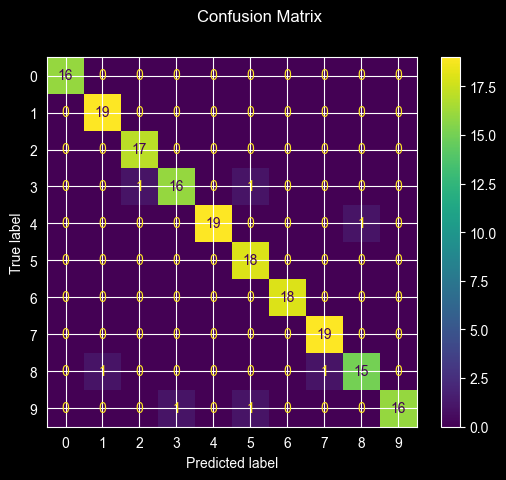

In [5]:
from sklearn import metrics
import matplotlib.pyplot as plt

knn.fit(x_train, y_train)
pred_knn = knn.predict(x_test)

disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_knn)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

In [ ]:
### Plot kết quả LogisticRegression

Confusion matrix:
[[16  0  0  0  0  0  0  0  0  0]
 [ 0 19  0  0  0  0  0  0  0  0]
 [ 0  0 17  0  0  0  0  0  0  0]
 [ 0  0  0 11  0  3  0  0  4  0]
 [ 0  0  0  0 18  0  0  0  0  2]
 [ 0  0  0  0  0 18  0  0  0  0]
 [ 0  0  0  0  0  0 18  0  0  0]
 [ 0  0  0  0  0  0  0 19  0  0]
 [ 0  0  0  0  0  0  0  1 16  0]
 [ 0  0  0  1  0  1  0  0  0 16]]


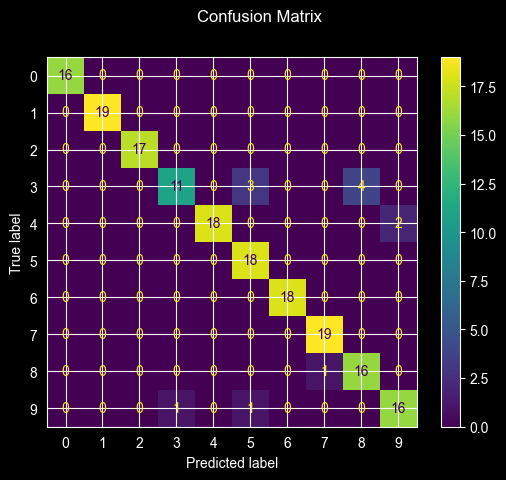

In [6]:
from sklearn import metrics
import matplotlib.pyplot as plt

logistic.fit(x_train, y_train)
pred_logistic = logistic.predict(x_test)

disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_logistic)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

### So sánh đúng và sai của 2 mô hình

In [7]:
import numpy as np

# Đảm bảo cả 2 mô hình đã có dự đoán
pred_knn = knn.predict(x_test)
pred_logistic = logistic.predict(x_test)

# Tạo mask đúng/sai
knn_correct = (pred_knn == y_test)
log_correct = (pred_logistic == y_test)

# 1. Lọc mẫu: Log sai - KNN đúng & KNN sai - Log đúng
idx_log_fail_knn_pass = np.where(~log_correct & knn_correct)[0]
idx_knn_fail_log_pass = np.where(~knn_correct & log_correct)[0]

# 2. Lọc mẫu: Cả 2 đều sai
idx_both_fail = np.where(~log_correct & ~knn_correct)[0]

# In kết quả (số lượng và 10 index đầu tiên)
print(f"Logistic Wrong / KNN Right ({len(idx_log_fail_knn_pass)}): {idx_log_fail_knn_pass[:10]}...")
print(f"KNN Wrong / Logistic Right ({len(idx_knn_fail_log_pass)}): {idx_knn_fail_log_pass[:10]}...")
print(f"Both Wrong ({len(idx_both_fail)}): {idx_both_fail[:10]}...")

Logistic Wrong / KNN Right (6): [ 11  63  73 109 112 113]...
KNN Wrong / Logistic Right (1): [173]...
Both Wrong (6): [ 41  43  45  49 110 148]...
